# Exploratory Data Analysis for Mashtots Dataset

## 1. Project Overview
### Objective

The goal of this project is to build a robust computer vision pipeline for classifying handwritten Armenian letters from grayscale images.

The notebook focuses on:

- Understanding dataset quality
- Identifying class imbalance
- Detecting acquisition artifacts
- Evaluating preprocessing strategies
- Understanding inter-class similarity

## 2. Imports and Configuration

In [ ]:
# Standard library
import os
import random
from pathlib import Path
from collections import Counter

# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Image processing
import cv2
from PIL import Image

In [ ]:
sns.set_style("whitegrid")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

DATA_DIR = Path("./data")

TRAIN_DIR = DATA_DIR / "Train" / "Train"

IMG_SIZE = (64, 64)

## 3. Dataset Loading

### Dataset Structure

Expected directory structure:

```text
data/
├── Train/
|   ├── Train/
    │   ├── class_0/
    │   ├── class_1/
    │   └── ...
└── new_test/
    new_test.csv
```


### Build DataFrame Metadata

In [26]:
def build_dataframe(root_dir):

    image_paths = []
    labels = []

    for class_dir in sorted(root_dir.iterdir()):

        if not class_dir.is_dir():
            continue

        label = class_dir.name

        for img_path in class_dir.glob("*"):

            image_paths.append(str(img_path))
            labels.append(label)

    return pd.DataFrame({
        "path": image_paths,
        "label": labels
    })
    
   

In [27]:
train_df = build_dataframe(TRAIN_DIR)

print(f"Train samples: {len(train_df)}")

Train samples: 70060


## 4. Dataset Integrity Checks

### Dataset Integrity Checks

Before training any model, it is important to verify:

* Missing files
* Corrupted images
* Image size consistency
* Label validity

Poor dataset integrity often causes unstable training behavior and misleading evaluation results.


### Missing Files

In [10]:
missing = train_df[
    ~train_df["path"].apply(os.path.exists)
]

print(f"Missing files: {len(missing)}")

Missing files: 0


### Corrupted Images

In [11]:
corrupted = []

for path in train_df["path"]:
    try:
        img = Image.open(path)
        img.verify()

    except Exception:
        corrupted.append(path)

print(f"Corrupted images: {len(corrupted)}")

Corrupted images: 0


### Image Size Consistency

In [12]:
sizes = []

for path in train_df["path"][:5000]:

    img = Image.open(path)

    sizes.append(img.size)

Counter(sizes).most_common()

[((64, 64), 5000)]

### Label Validity

The Official Kaggle page of the Dataset suggests the following label structure.

- Ա-Ֆ -> 0-38
- ա-ֆ -> 39-77

Let us make sure that the labels in the dataset are in this range.

In [28]:
unique_labels = np.unique(train_df["label"])
unique_values = [int(label) for label in unique_labels]

print(f"Smallest Label Value {min(unique_values)}")
print(f"Largest Label Value {max(unique_values)}")

Smallest Label Value 0
Largest Label Value 77


## 5. Dataset Overview

### Class Distribution Analysis

Understanding label balance is critical because:

* Imbalanced datasets bias models toward majority classes
* Minority classes often suffer lower recall
* Weighted loss or oversampling may become necessary


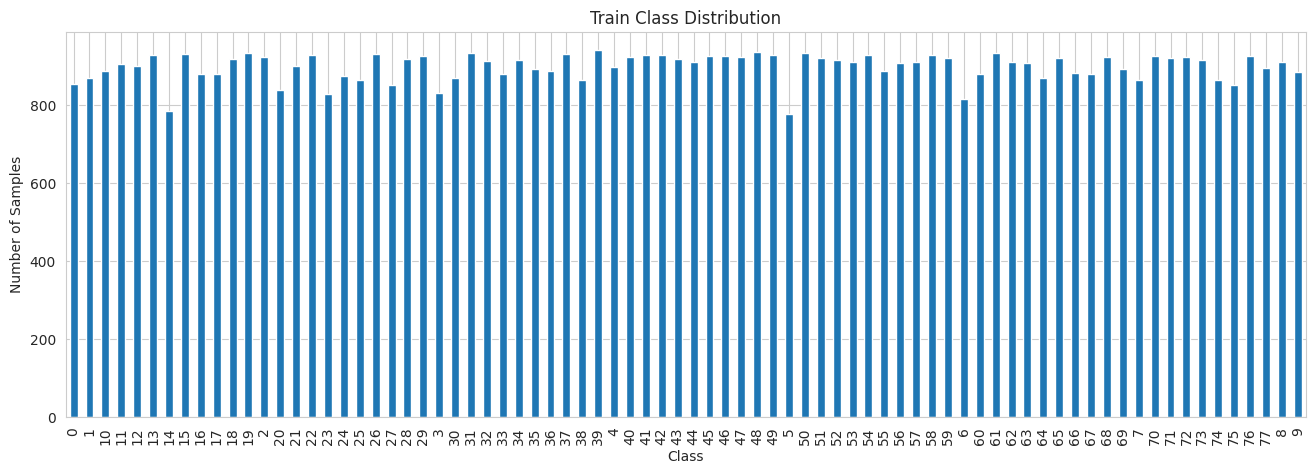

In [35]:
train_counts = (
    train_df["label"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(16, 5))

train_counts.plot(kind="bar")

plt.title("Train Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")

plt.show()

In [36]:
imbalance_ratio = (
    train_counts.max() /
    train_counts.min()
)

print(f"Imbalance ratio: {imbalance_ratio:.2f}")

Imbalance ratio: 1.21


### Visual Inspection

Visual inspection is one of the most important parts of computer vision EDA.

This helps identify:

* Stroke thickness variability
* Misaligned characters
* Noise
* Broken characters
* Unusual writing styles
* Potential labeling issues


In [49]:
def load_grayscale(path):

    return cv2.imread(
        path,
        cv2.IMREAD_GRAYSCALE
    )

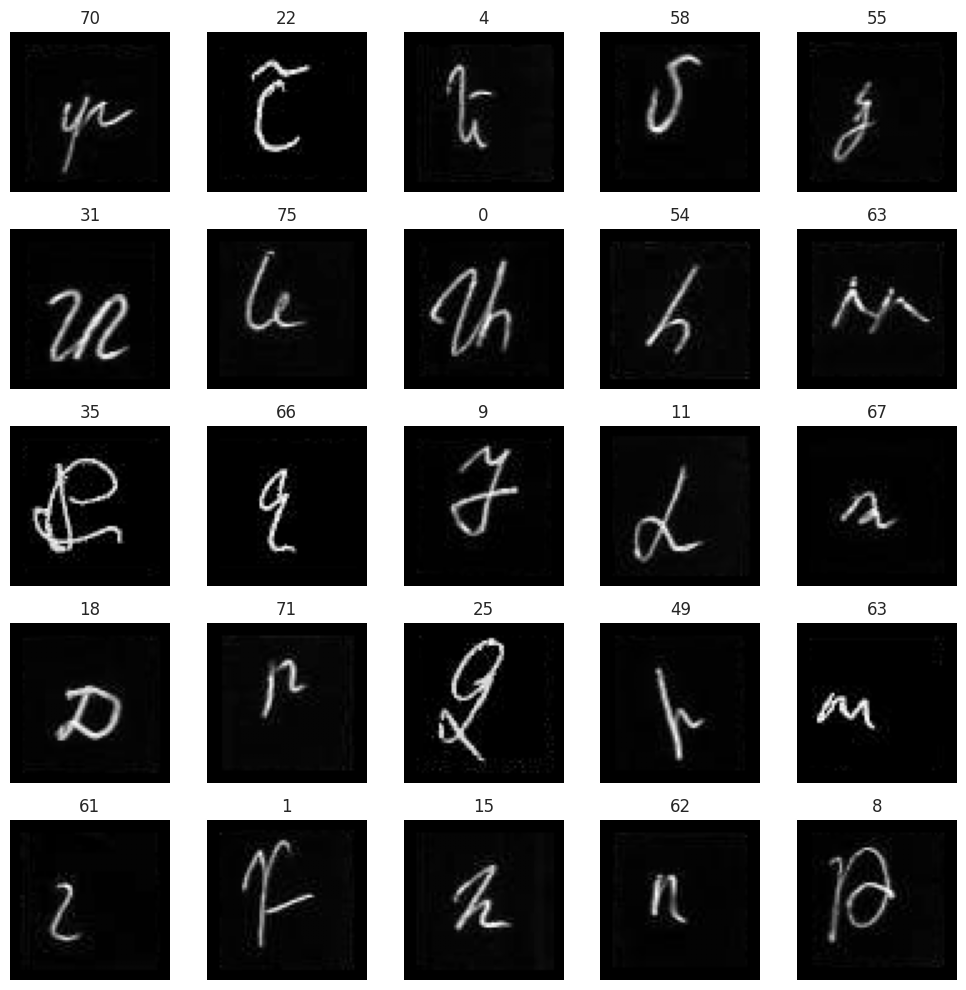

In [50]:
samples = train_df.sample(
    25,
    random_state=SEED
)

fig, axes = plt.subplots(
    5,
    5,
    figsize=(10, 10)
)

for ax, (_, row) in zip(
    axes.flatten(),
    samples.iterrows()
):

    img = load_grayscale(row["path"])

    ax.imshow(img, cmap="gray")
    ax.set_title(row["label"])
    ax.axis("off")

plt.tight_layout()
plt.show()

### Pixel Statistics

Pixel-level statistics help determine:

* Appropriate normalization values
* Contrast characteristics
* Thresholding suitability
* Dynamic range consistency


In [51]:
all_pixels = []

for path in train_df["path"]:

    img = load_grayscale(path)

    img = img.astype(np.float32) / 255.0

    all_pixels.append(img.flatten())

all_pixels = np.concatenate(all_pixels)

### Mean and Varaince of the Values

In [52]:
mean = np.mean(all_pixels)
std = np.std(all_pixels)

print(f"Mean: {mean:.5f}")
print(f"Std: {std:.5f}")

Mean: 0.03343
Std: 0.10352
